In [13]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv"
df = pd.read_csv(url, low_memory=False) # I got this warning DtypeWarning and it told me to add this

df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [14]:
df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

df = df.dropna(subset=["price", "reviews per month"])

In [18]:
def viz_corr(x: str, y: str):
    plt.figure(figsize=(10,6))
    r, p = stats.pearsonr(df[x], df[y])
    r2 = r**2
    reg = sns.regplot(data=df, x=x, y=y, line_kws={"color": "red"})
    text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
    reg.text(
        0.1,
        0.7,
        text,
        transform=reg.transAxes,
        bbox={"boxstyle": "round, pad=0.5", "fc": "white"}
    )
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()

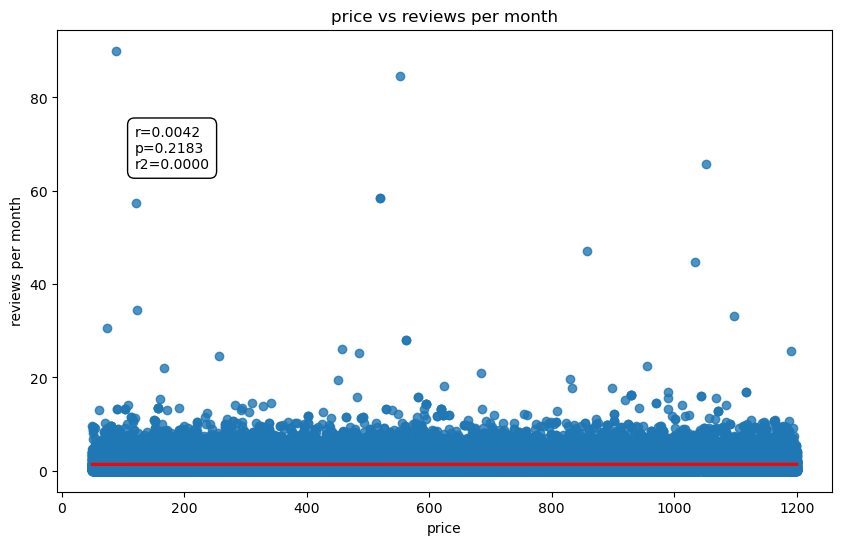

In [19]:
viz_corr("price", "reviews per month")

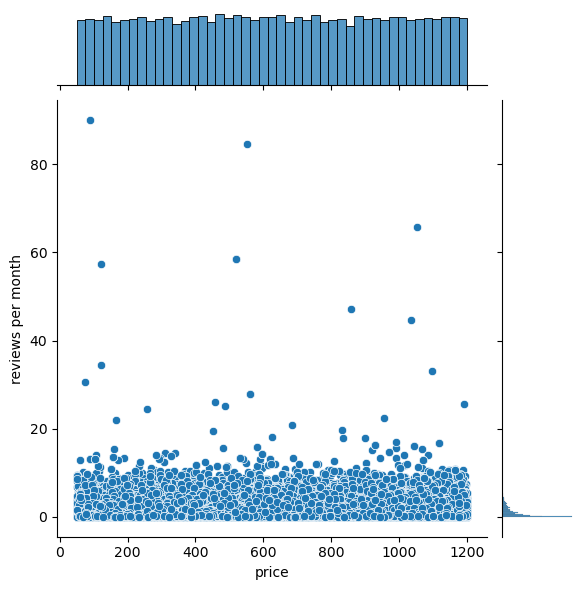

In [20]:
sns.jointplot(
    data=df,
    x="price",
    y="reviews per month"
)